In [3]:
import pandas as pd
import numpy as np 


In [ ]:
train_csv_path= "../data/amia-public-challenge-2026/train.csv"
df= pd.read_csv(train_csv_path)
df.head()

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,bM8C97htulC9fHKIDurJHquCXr1KZuug,No finding,14,R5,NaN,NaN,NaN,NaN
1,0FDQVdLgDKI1sRnPL94LzVh9EvXDVM9m,Aortic enlargement,0,R10,1148.0,503.0,1466.0,823.0
2,Dwk2TnGJFaMhyi3OfCrhdZG9ppGglC5w,Consolidation,4,R8,264.0,732.0,550.0,1119.0
3,vqw6mWifHgCf8jmTotrMAS3qCk5eJuc4,No finding,14,R13,NaN,NaN,NaN,NaN
4,EzfCkMwi4E5bAtZZo4brqt9dNbm7sF9z,No finding,14,R5,NaN,NaN,NaN,NaN


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45925 entries, 0 to 45924
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image_id    45925 non-null  str    
 1   class_name  45925 non-null  str    
 2   class_id    45925 non-null  int64  
 3   rad_id      45925 non-null  str    
 4   x_min       30400 non-null  float64
 5   y_min       30400 non-null  float64
 6   x_max       30400 non-null  float64
 7   y_max       30400 non-null  float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.8 MB


In [9]:
df.nunique()

image_id      8573
class_name      15
class_id        15
rad_id          17
x_min         2504
y_min         2549
x_max         2627
y_max         2690
dtype: int64

In [13]:
df['class_name'].value_counts(dropna=False)

class_name
No finding            15525
Aortic enlargement     5481
Pleural thickening     4308
Pulmonary fibrosis     4097
Cardiomegaly           4046
Nodule/Mass            2324
Pleural effusion       2190
Lung Opacity           2188
Other lesion           1945
Infiltration           1097
ILD                     904
Calcification           851
Consolidation           519
Atelectasis             255
Pneumothorax            195
Name: count, dtype: int64

In [14]:
df['class_id'].value_counts(dropna=False)

class_id
14    15525
0      5481
11     4308
13     4097
3      4046
8      2324
10     2190
7      2188
9      1945
6      1097
5       904
2       851
4       519
1       255
12      195
Name: count, dtype: int64

In [23]:
null_df=(df['class_id']!= 14) & (df['x_min'].isnull() | df['y_min'].isnull() | df['x_max'].isnull() | df['y_max'].isnull())
null_df.value_counts()

False    45925
Name: count, dtype: int64

In [28]:
df.groupby('image_id')['class_id'].nunique().value_counts()

class_id
1     5344
2      788
3      763
4      647
5      476
6      286
7      172
8       71
9       22
10       4
Name: count, dtype: int64

8573 unique images across 15 classes (0 to 14 , 14 being no finding)
No missing labels. Every entry has a class assigned. And every row that has a disease assigned has valid bounding box coordinates. 
Some images have upto 10 diseases assigned (i.e to say some images have multiple classes assigned). 

In [36]:
import os
train_image_path= "../data/amia-public-challenge-2026/train/train"
files = [f.replace('.png', '') for f in os.listdir(train_image_path) if os.path.isfile(os.path.join(train_image_path, f))]
files= set(files)
images= set(df['image_id'].unique())
missing_images= images - files
print(f"Missing images: {missing_images}")


Missing images: set()


All images are present. 

In [43]:
df['rad_id'].nunique()

17

17 Radiologists in total. But how were they assigned? multiple radiologists evaluated multiple images? let's look at one image to see. 

In [45]:
df.loc[df['image_id'] == 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx']

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
8,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Nodule/Mass,8,R8,1594.0,1222.0,1743.0,1381.0
5934,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Aortic enlargement,0,R10,1200.0,545.0,1480.0,848.0
10285,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Cardiomegaly,3,R8,846.0,1327.0,1829.0,1769.0
13943,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Cardiomegaly,3,R9,859.0,1340.0,1833.0,1716.0
19999,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Aortic enlargement,0,R8,1209.0,537.0,1482.0,932.0
20575,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Infiltration,6,R9,494.0,1148.0,915.0,1687.0
21566,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Other lesion,9,R9,494.0,1148.0,915.0,1687.0
25307,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Nodule/Mass,8,R9,1601.0,1234.0,1746.0,1368.0
40165,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Nodule/Mass,8,R10,1600.0,1242.0,1747.0,1377.0
41641,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Cardiomegaly,3,R10,851.0,1417.0,1856.0,1759.0


In [58]:
list_no_radiologists_for_an_image=df.groupby('image_id')['rad_id'].nunique()
print("No. of radiologists|| No. of images")
print(list_no_radiologists_for_an_image.value_counts())

No. of radiologists|| No. of images
rad_id
3    8573
Name: count, dtype: int64


Every image was evaluated by 3 radiologists. So there are three possible distinct classes & boundary boxes asssigned to an image. 

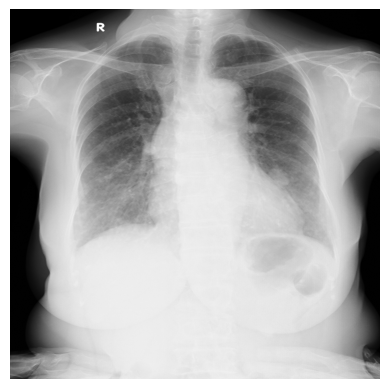

In [40]:
import matplotlib.pyplot as plt
sample_image_path= os.path.join(train_image_path, 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx.png')  
# Load the image
img = plt.imread(sample_image_path)

# Display the image
plt.imshow(img, cmap='gray')
plt.axis('off')  
plt.show()   

In [39]:
img.shape

(1024, 1024)

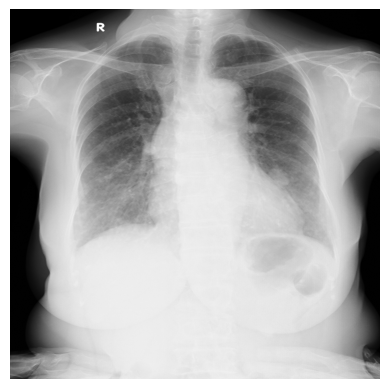

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
fig, ax = plt.subplots()
image_path= os.path.join(train_image_path, 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx.png')  
# Load the image
img = plt.imread(image_path)

# Display the image
ax.imshow(img, cmap='gray')
ax.axis('off')  

rows_of_image =df.loc[df['image_id']== 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx'] 
#print(rows_of_image)

for index, row in rows_of_image.iterrows():
    rect= Rectangle((row['x_min'], row['y_min']), row['x_max']- row['x_min'], row['y_max']- row['y_min'], 
                    fill= False, edgecolor='red', linewidth=2, alpha=0.5)
    ax.add_patch(rect)

plt.show()


The boundary boxes aren't being drawn. As mentioned in the discussions, boundary box coordinates are according to actual image size as per in img_size.csv and not in the 1024x1024 that we have the images in. So resizing the 

In [81]:
image_size_df= pd.read_csv("../data/amia-public-challenge-2026/img_size.csv")
image_size= image_size_df.loc[image_size_df['image_id'] == 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx']
x, y= image_size['dim0'], image_size['dim1']
original_x, original_y= x.values[0], y.values[0]
print(f"Image dimensions: { original_x} x {original_y}")

Image dimensions: 2880 x 2304


In [82]:
x_scale= 1024/original_x
y_scale= 1024/original_y
print(f"X scale factor: {x_scale}") 
print(f"Y scale factor: {y_scale}")

X scale factor: 0.35555555555555557
Y scale factor: 0.4444444444444444


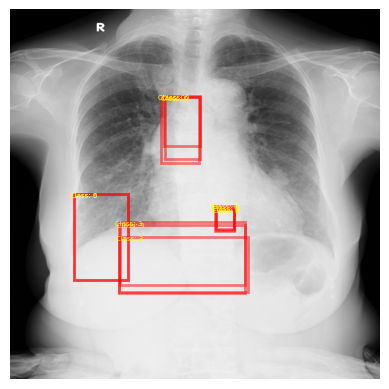

In [86]:

fig, ax = plt.subplots()
image_path= os.path.join(train_image_path, 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx.png')  
# Load the image
img = plt.imread(image_path)

# Display the image
ax.imshow(img, cmap='gray')
ax.axis('off')  

rows_of_image =df.loc[df['image_id']== 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx'] 
#print(rows_of_image)

for index, row in rows_of_image.iterrows():
    rect= Rectangle((row['x_min']*x_scale, row['y_min']*y_scale), (row['x_max']- row['x_min'])*x_scale, (row['y_max']- row['y_min'])*y_scale, 
                    fill= False, edgecolor='red', linewidth=2, alpha=0.5)
    ax.add_patch(rect)
    ax.text(row['x_min']*x_scale-10, row['y_min']*y_scale-5, f"Class: {row['class_id']}", color='yellow', fontsize=5, verticalalignment='top')

plt.show()

Since 3 radiologists have marked this image, it looks cluttered, let's make a separate plot for each radiologist. 

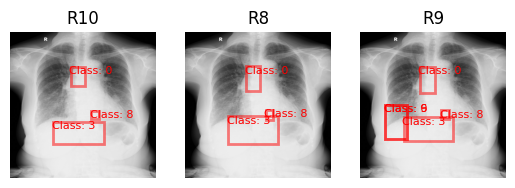

In [93]:
fig, ax = plt.subplots(nrows=1, ncols=3)
image_path= os.path.join(train_image_path, 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx.png')  
# Load the image
img = plt.imread(image_path)

rows_of_image =df.loc[df['image_id']== 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx'] 

for rowsofgroups, individual in zip(rows_of_image.groupby('rad_id'), ax):
    individual.imshow(img, cmap='gray')
    individual.axis('off')
    rad_id, group= rowsofgroups
    for index, row in group.iterrows():
        rect= Rectangle((row['x_min']*x_scale, row['y_min']*y_scale), (row['x_max']- row['x_min'])*x_scale, (row['y_max']- row['y_min'])*y_scale, 
                                fill= False, edgecolor='red', linewidth=2, alpha=0.5)
        individual.add_patch(rect)
        individual.text(row['x_min']*x_scale-10, row['y_min']*y_scale-5, f"Class: {row['class_id']}", color='red', fontsize=8, verticalalignment='top')
        individual.set_title(rad_id)

plt.show()